# Multiple Linear Regression - Marketing Sales Analysis

**Goal:** Build a multiple linear regression model to predict `Sales` from marketing channel data (`TV`, `Radio`, `Social Media`), check for multicollinearity among predictors, validate model assumptions, and translate the results into a prioritized, evidence-based recommendation for marketing budget allocation.

**Dataset:** `marketing_sales_data.csv`
Columns: `TV` (categorical: Low / Medium / High), `Radio` (numeric), `Social Media` (numeric), `Influencer` (categorical), `Sales` (numeric)


## Setup: Import Libraries

In [7]:
# Import packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [8]:
from google.colab import files
uploaded = files.upload()

Saving marketing_sales_data.csv to marketing_sales_data (1).csv


## Step 1: Load the Dataset and Perform Initial EDA

We start by loading the dataset and getting a first look at its shape, columns, data types, and any missing values.

In [9]:
# Load dataset
df = pd.read_csv("marketing_sales_data.csv")

# Rename column for easier reference in formulas (no spaces)
df = df.rename(columns={"Social Media": "Social_Media"})

print(df.shape)
df.head()


(572, 5)


,TV,Radio,Social_Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [10]:
# Check data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social_Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB


In [11]:
# Check for missing values
df.isnull().sum()


,0
TV,0
Radio,0
Social_Media,0
Influencer,0
Sales,0


Good news  -  there are no missing values in this dataset, so no cleaning is required.

`TV` and `Influencer` are categorical variables. Let's check their categories.

In [12]:
# Check unique categories for TV and Influencer
print("TV categories:", df["TV"].unique())
print("Influencer categories:", df["Influencer"].unique())


TV categories: ['Low' 'High' 'Medium']
Influencer categories: ['Micro' 'Mega' 'Nano' 'Macro']


In [13]:
# Summary statistics for numeric columns
df.describe()


,Radio,Social_Media,Sales
count,572.000000,572.000000,572.000000
mean,17.520616,3.333803,189.296908
std,9.290933,2.238378,89.871581
min,0.109106,0.000031,33.509810
25%,10.699556,1.585549,118.718722
50%,17.149517,3.150111,184.005362
75%,24.606396,4.730408,264.500118
max,42.271579,11.403625,357.788195


### Exploratory Visualizations

Let's look at how Sales relates to each marketing channel.

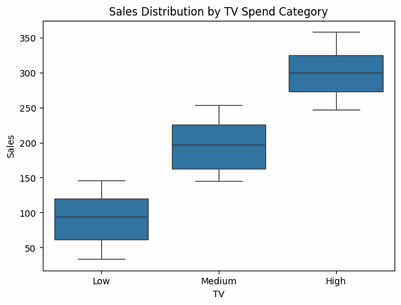

In [14]:
# Boxplot of Sales by TV spend category
plt.figure(figsize=(7, 5))
sns.boxplot(x="TV", y="Sales", data=df, order=["Low", "Medium", "High"])
plt.title("Sales Distribution by TV Spend Category")
plt.show()


The boxplot shows a clear pattern: companies with a **High** TV spend category have substantially higher Sales than those with **Medium** or **Low** TV spend, and there's very little overlap between the groups. This suggests `TV` will be a strong predictor of `Sales`.

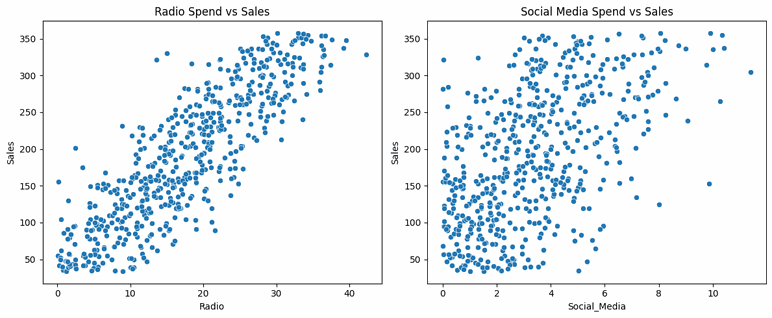

In [15]:
# Scatterplots of Radio and Social Media vs Sales
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x="Radio", y="Sales", data=df, ax=axes[0])
axes[0].set_title("Radio Spend vs Sales")

sns.scatterplot(x="Social_Media", y="Sales", data=df, ax=axes[1])
axes[1].set_title("Social Media Spend vs Sales")

plt.tight_layout()
plt.show()


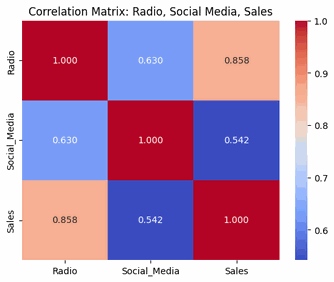

In [16]:
# Correlation matrix for the numeric variables
sns.heatmap(df[["Radio", "Social_Media", "Sales"]].corr(), annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Matrix: Radio, Social Media, Sales")
plt.show()


`Radio` shows a fairly strong positive correlation with `Sales` (~ 0.86), while `Social Media` shows a weaker correlation (~ 0.54). `Radio` and `Social Media` are also moderately correlated with each other (~ 0.63), which we'll investigate further in the multicollinearity check below.

## Step 2: Check for Multicollinearity

Multicollinearity occurs when independent variables are highly correlated with each other, which can make coefficient estimates unstable and hard to interpret. We'll check this using:

1. A **correlation matrix** among the independent variables
2. **Variance Inflation Factor (VIF)** for each predictor  -  a VIF above 5 (some use 10) suggests problematic multicollinearity

Since `TV` is categorical, we first convert it into dummy/indicator variables so it can be included in the numeric design matrix used for VIF.

In [17]:
# One-hot encode TV (drop the first category to avoid the dummy variable trap)
# This creates TV_Low and TV_Medium, with "High" as the reference/baseline category
tv_dummies = pd.get_dummies(df["TV"], prefix="TV", drop_first=True).astype(float)

# Build the predictor matrix for the multicollinearity check
X_check = pd.concat([df[["Radio", "Social_Media"]], tv_dummies], axis=1)
X_check.head()


,Radio,Social_Media,TV_Low,TV_Medium
0,3.518070,2.293790,1.0,0.0
1,7.756876,2.572287,1.0,0.0
2,20.348988,1.227180,0.0,0.0
3,20.108487,2.728374,0.0,1.0
4,31.653200,7.776978,0.0,0.0


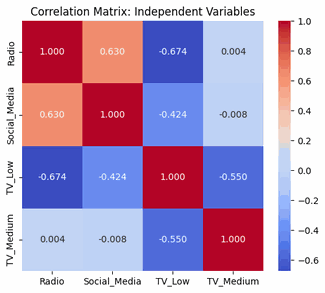

In [18]:
# Correlation matrix among predictors
plt.figure(figsize=(6, 5))
sns.heatmap(X_check.corr(), annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Matrix: Independent Variables")
plt.show()


In [19]:
# Compute VIF for each predictor
X_vif = sm.add_constant(X_check)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_check.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i + 1) for i in range(len(X_check.columns))]

vif_data


,Variable,VIF
0,Radio,3.462738
1,Social_Media,1.658537
2,TV_Low,4.064612
3,TV_Medium,2.217533


All VIF values are below 5 (the highest is for `TV_Low` at around 4, reflecting its moderate negative correlation with `Radio`). This indicates **no severe multicollinearity** among our predictors  -  we can proceed with all of them in the regression model, while keeping an eye on `Social_Media`'s contribution given its correlation with `Radio`.

## Step 3: Build the Multiple Linear Regression Model

We'll model `Sales` as a function of `Radio`, `Social_Media`, and `TV` (as a categorical variable) using `statsmodels`. The `C()` notation tells `statsmodels` to treat `TV` as categorical and automatically create dummy variables, using the first category alphabetically (`High`) as the baseline/reference group.

In [20]:
# Build and fit the multiple regression model
ols_formula = "Sales ~ Radio + Social_Media + C(TV)"

OLS = ols(ols_formula, data=df)
model = OLS.fit()

# View the model summary
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1335.
Date:                Mon, 15 Jun 2026   Prob (F-statistic):          7.29e-287
Time:                        02:56:37   Log-Likelihood:                -2713.9
No. Observations:                 572   AIC:                             5438.
Df Residuals:                     567   BIC:                             5460.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         218.6473      6.290     34.761      0.000     206.293     231.002
C(TV)[T.Low]     -154.3121      4.934    -31.277      0.000    -164.003    -144.622
C(TV)[T.Medium]   -75.3279      3.628    -20.763      0.000     -82.454     -68.202
Radio               2.9891      0.234     12.763      0.000       2.529       3.449
Social_Media       -0.1500      0.673     -0.223      0.824      -1.471       1.171
==============================================================================
Omnibus:                       60.947   Durbin-Watson:                   1.872
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.035
Skew:                           0.046   Prob(JB):                     0.000121
Kurtosis:                       2.135   Cond. No.                         144.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Step 4: Evaluate Model Performance

Looking at the model summary above:

- **Adjusted R-squared ~ 0.903**  -  about 90.3% of the variation in Sales is explained by this model (adjusted R-squared accounts for the number of predictors, so it's a fairer comparison than plain R-squared when adding/removing variables).
- **`Radio` (p ~ 0.000)**  -  statistically significant
- **`C(TV)[T.Low]` and `C(TV)[T.Medium]` (p ~ 0.000)**  -  both statistically significant
- **`Social_Media` (p ~ 0.824)**  -  **not** statistically significant at any conventional threshold (p > 0.05)

Since `Social_Media` is not a statistically significant predictor once `Radio` and `TV` are accounted for (likely due to its correlation with `Radio`), we refit the model without it to get a more parsimonious, interpretable model.

In [21]:
# Refit the model without Social_Media
ols_formula_reduced = "Sales ~ Radio + C(TV)"

OLS_reduced = ols(ols_formula_reduced, data=df)
model_reduced = OLS_reduced.fit()

model_reduced.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     1783.
Date:                Mon, 15 Jun 2026   Prob (F-statistic):          1.63e-288
Time:                        02:56:39   Log-Likelihood:                -2714.0
No. Observations:                 572   AIC:                             5436.
Df Residuals:                     568   BIC:                             5453.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         218.5261      6.261     34.902      0.000     206.228     230.824
C(TV)[T.Low]     -154.2971      4.929    -31.303      0.000    -163.979    -144.616
C(TV)[T.Medium]   -75.3120      3.624    -20.780      0.000     -82.431     -68.193
Radio               2.9669      0.212     14.015      0.000       2.551       3.383
==============================================================================
Omnibus:                       61.244   Durbin-Watson:                   1.870
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.077
Skew:                           0.046   Prob(JB):                     0.000119
Kurtosis:                       2.134   Cond. No.                         142.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Dropping `Social_Media` barely changes the Adjusted R-squared (from ~ 0.9033 to ~ 0.9035), confirming it added no meaningful explanatory power. Both `Radio` and `TV` remain highly significant (p < 0.001) in this reduced model. **We'll use this reduced model (`Sales ~ Radio + C(TV)`) going forward.**

## Step 5: Diagnostic Plots  -  Validating Model Assumptions

Multiple linear regression relies on the same core assumptions as simple linear regression:

1. **Linearity**  -  the relationship between predictors and the outcome is linear
2. **Independent observations**  -  each row is an independent record
3. **Normality**  -  residuals are normally distributed
4. **Homoscedasticity**  -  residuals have constant variance across fitted values

We already explored linearity for `Radio` vs `Sales` in our EDA scatterplot. **Independence** is assumed based on how the data was collected (each row represents a separate company/observation). Now let's check normality and homoscedasticity using the residuals from our reduced model.

In [22]:
# Get fitted values and residuals from the reduced model
fitted_values = model_reduced.predict(df)
residuals = model_reduced.resid


### Checking the Normality Assumption

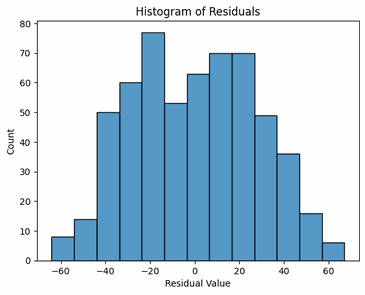

In [23]:
# Histogram of residuals
fig = sns.histplot(residuals)
fig.set_xlabel("Residual Value")
fig.set_title("Histogram of Residuals")
plt.show()


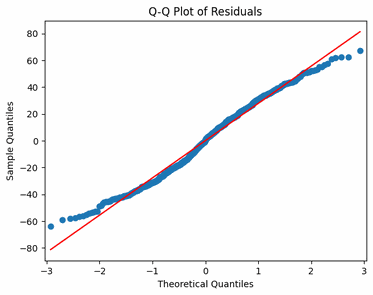

In [24]:
# Q-Q plot of residuals
fig = sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()


The histogram of residuals looks roughly bell-shaped and centered around zero, and the Q-Q plot follows the diagonal reference line closely in the middle of the distribution, with some minor deviation in the tails. Overall, the normality assumption is **reasonably well satisfied**  -  there's no severe skew or extreme departure from normality that would invalidate the model's inference.

### Checking the Homoscedasticity Assumption

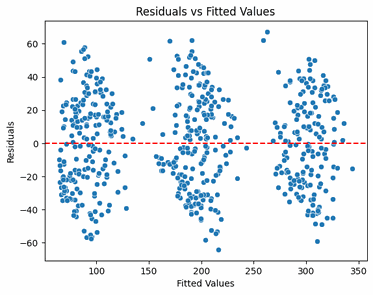

In [25]:
# Scatterplot of fitted values vs residuals
fig = sns.scatterplot(x=fitted_values, y=residuals)
fig.axhline(0, color="red", linestyle="--")
fig.set_xlabel("Fitted Values")
fig.set_ylabel("Residuals")
fig.set_title("Residuals vs Fitted Values")
plt.show()


The residuals are scattered in three roughly horizontal bands (corresponding to the three `TV` categories  -  Low, Medium, High), each centered around zero with no clear funnel shape or pattern of increasing/decreasing spread. This supports the **homoscedasticity assumption**  -  the model's prediction error doesn't systematically grow or shrink with the size of the prediction.

## Step 6: Interpreting Coefficients & Business Recommendation

### Model Equation

From the reduced model (`Sales ~ Radio + C(TV)`), with **High TV spend as the reference category**:

```
Sales ~ 218.53 + 2.97 x Radio - 154.30 x TV_Low - 75.31 x TV_Medium
```

### Coefficient Interpretations

- **Intercept (~ 218.53)**: The predicted Sales for a company with `Radio` spend = 0 and a **High** TV spend category.
- **Radio (~ 2.97, p < 0.001)**: **Holding the TV spend category constant**, each additional \$1K spent on Radio is associated with an estimated **\$2.97K increase in Sales**. This is a precise, statistically reliable effect.
- **TV_Low (~ -154.30, p < 0.001)**: **Holding Radio spend constant**, companies in the **Low** TV spend category have, on average, about **\$154.30K lower Sales** than companies in the **High** TV spend category.
- **TV_Medium (~ -75.31, p < 0.001)**: **Holding Radio spend constant**, companies in the **Medium** TV spend category have, on average, about **\$75.31K lower Sales** than companies in the **High** TV spend category.

### Model Fit

- **Adjusted R-squared ~ 0.9035**  -  this model explains about 90% of the variation in Sales, which is a strong fit for a business dataset.
- **F-statistic p-value < 0.001**  -  the model as a whole is highly statistically significant.

### Explaining This to a Non-Technical Stakeholder

> "We built a model to understand what drives Sales using three marketing channels: TV, Radio, and Social Media spend. After testing all three, we found that **Social Media spend did not meaningfully contribute to Sales** once we accounted for TV and Radio  -  so we removed it to keep the model simple and focused.
>
> The two channels that matter are **TV spend category** and **Radio spend**:
> - Moving from a **Low** to a **High** TV spend category is associated with roughly a **\$154K increase in Sales** on average, holding Radio constant  -  the single largest driver we found.
> - Moving from **Medium** to **High** TV spend is associated with roughly a **\$75K increase in Sales**.
> - For Radio, every additional **\$1,000** spent is associated with roughly **\$2,970** in additional Sales, regardless of TV spend level.
>
> Together, this model explains about **90% of the variation in Sales** across companies in our dataset  -  a very strong result."

### Business Recommendation

Based on this analysis, our prioritized, evidence-based recommendation for marketing budget allocation is:

1. **Prioritize moving into the "High" TV spend category.** This single factor is associated with the largest difference in Sales (~ \$154K vs. Low, ~ \$75K vs. Medium), and the effect is highly statistically significant.
2. **Continue investing in Radio as a secondary, scalable channel.** Its effect (~ \$2.97K in Sales per additional \$1K spent) is statistically reliable and, unlike the TV categories, scales continuously  -  every incremental dollar contributes.
3. **De-prioritize Social Media spend for short-term Sales impact**, or treat it as serving other goals (e.g., brand awareness, engagement) rather than direct Sales lift  -  our model found no statistically significant relationship between Social Media spend and Sales once TV and Radio were accounted for.

**Caveat:** `TV` in this dataset is a *spend category* (Low/Medium/High), not a continuous dollar amount, so we can't directly compute a "\$ per \$ spent" ROI for TV the way we can for Radio. A useful next step would be to obtain the actual TV spend amounts to quantify TV's ROI on the same scale as Radio.